In [1]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pickle
from scipy import stats

import covid19_inference.covid19_inference as cov19
import utils

# increase plt fontsize
plt.rcParams.update({'font.size': 20})

from matplotlib import lines, patches

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (aesara.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (aesara.configdefaults): g++ not detected!  Aesara will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set Aesara flags cxx to an empty string.
WARNING (aesara.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['viridis']

color_m_base = colormap(0.0)
color_m_obs = colormap(0.2)
color_m = colormap(0.2)

color_R = colormap(0.4)
color_del_m_R = colormap(0.4)
#color_m_R = colormap(0.4)

color_C = colormap(0.6)
color_del_m_C = colormap(0.6)
#color_m_C = colormap(0.7)

color_ICU = colormap(0.8)
color_del_m_ICU = colormap(0.8)
#color_m_ICU = colormap(1.0)

# Input data

## Mobility

In [3]:
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week

# get dates
mobility_dates = mobility_df.index.values
mobility_dates_2020 = mobility_dates[mobility_dates < np.datetime64('2020-12-20')]
mobility_dates_2020 = mobility_dates_2020[mobility_dates_2020 > np.datetime64('2020-03-15')]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64('2022-12-20')]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020):]

# get mobility data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_df_2022 = mobility_df.filter(items=mobility_dates_2022_shortened, axis=0)

mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()
mobility_data_2022 = mobility_df_2022["outOfHomeDuration"].to_xarray()

## Effective Reproduction Number

In [4]:
path_R = "data/R/Germany/R_eff_Germany.csv"
R_df = pd.read_csv(path_R, index_col=1, parse_dates=True)

# weekly average placed on Sunday
df = utils.weekly_formatting(R_df, mobility_dates_2020)
df = utils.transform_data(df["R_eff median"])
R_data = df.to_xarray()

# plot R data
#R_data.plot()

## Our World in Data

In [5]:
owid = cov19.data_retrieval.OWD()
owid.download_all_available_data()
#owid.data.columns

INFO     [covid19_inference.covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from C:\Users\iftek\AppData\Local\Temp/covid19_data/, skipping download.


### ICU

In [6]:
ICU_data = owid._filter(
    value = "icu_patients_per_million", 
    country="Germany", 
    )
ICU_data = utils.weekly_formatting(ICU_data, mobility_dates_2020)
ICU_data = utils.transform_data(ICU_data).to_xarray()
#ICU_data

### Cases

In [7]:
case_data = owid._filter(
    value = "new_cases_smoothed_per_million", 
    country="Germany", 
    )
case_data = utils.weekly_formatting(case_data, mobility_dates_2020)
case_data = utils.transform_data(case_data).to_xarray()

## Non-pharmaceutical interventions

In [8]:
stay_at_home_2020 = utils.get_NPI_data("data/NPIs/stay-at-home-covid.csv", mobility_dates_2020)
#movement_restrictions_2020 = utils.get_NPI_data("data/NPIs/internal-movement-covid.csv", mobility_dates_2020)
#public_transport_2020 = utils.get_NPI_data("data/NPIs/public-transport-covid.csv", mobility_dates_2020)

c:\Users\iftek\Documents\MPI\mobility inference\mobility_inference\utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()


# Bayesian Inference

## Cases model

In [23]:
n = case_data.shape[0]
with pm.Model() as C_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    cases_data = pm.ConstantData('cases', case_data, dims=['time'])

    # define priors
    c = pm.Normal('c', mu=1.0, sigma=0.1)
    mu_C = pm.LogNormal('mu_C', mu=0.8, sigma=0.2)
    sigma_C = pm.LogNormal('sigma_C', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    C_model.sim_len = n
    C_model.diff_data_sim = 16
    risk =  cov19.model.delay_cases(            
        cases=cases_data,
        delay_kernel="gamma",
        median_delay=mu_C,
        scale_delay=sigma_C,
        )

    del_m_C = - c * risk
    del_m_C = pm.Deterministic('del_m_C', del_m_C)

    # define likelihood
    m_C = pm.Deterministic("m_C", m_base_data + del_m_C)
    likelihood = pm.Normal('likelihood', mu=m_C, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [23]:
# inference
C_trace = pm.sample(model=C_model, draws=200, tune=200, cores=4, chains=4)
with C_model:
    pm.compute_log_likelihood(C_trace)

# Saving the results
tag = "C_model_test"	
# Save the trace
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(C_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO     [pymc] Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, mu_C, sigma_C, sigma]
INFO     [pymc] NUTS: [c, mu_C, sigma_C, sigma]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 6 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 6 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 6 seconds.


## R model

In [5]:
n = R_data.shape[0]
with pm.Model() as R_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=1, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # NEED TO UNDERSTAND THE KERNEL BETTER
    R_model.sim_len = n
    R_model.diff_data_sim = 16
    risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )

    del_m_R = - a * risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # define likelihood
    m_R = pm.Deterministic("m_R", m_base_data + del_m_R)
    likelihood = pm.Normal('likelihood', mu=m_R, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [14]:
# inference
R_trace = pm.sample(model=R_model, draws=200, tune=200, cores=1, chains=4)
with R_model:
    pm.compute_log_likelihood(R_trace)

# Saving the results
tag = "R_model_test"	
# Save the trace
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(R_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 2836 seconds.


## ICU model

In [25]:
n = ICU_data.shape[0]
with pm.Model() as ICU_model:
    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    icu_data = pm.ConstantData('ICU', ICU_data, dims=['time'])

    # define priors
    b = pm.Normal('b', mu=1.0, sigma=0.1)
    mu_ICU = pm.LogNormal('mu_ICU', mu=1, sigma=0.5)
    sigma_ICU = pm.LogNormal('sigma_ICU', mu=0.5, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # NEED TO UNDERSTAND THE KERNEL BETTER
    #R_model.shape_of_regions = 1
    ICU_model.sim_len = n
    ICU_model.diff_data_sim = 16
    risk = cov19.model.delay_cases(            
        cases=icu_data,
        delay_kernel="gamma",
        median_delay=mu_ICU,
        scale_delay=sigma_ICU,
        )

    del_m_ICU = - b * risk
    del_m_ICU = pm.Deterministic('del_m_ICU', del_m_ICU)

    # define likelihood
    m_ICU = pm.Deterministic("m_ICU", m_base_data + del_m_ICU)
    likelihood = pm.Normal('likelihood', mu=m_ICU, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [32]:
# inference
ICU_trace = pm.sample(model=ICU_model, draws=200, tune=200, cores=1, chains=4)

# Saving the results
# Save the trace
tag = "ICU_model_test"	
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(ICU_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\multipledispatch\dispatcher.py:27: AmbiguityWarning: 
Ambiguities exist in dispatched function _unify

The following signatures may result in ambiguous behavior:
	[object, ConstrainedVar, Mapping], [ConstrainedVar, Var, Mapping]
	[ConstrainedVar, object, Mapping], [object, ConstrainedVar, Mapping]
	[ConstrainedVar, object, Mapping], [object, ConstrainedVar, Mapping]
	[ConstrainedVar, Var, Mapping], [object, ConstrainedVar, Mapping]


Consider making the following additions:

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)
  warn(warning_text(dispatcher.name, ambiguities), AmbiguityWarning)
Auto-assigning NUTS sampler...
INFO     [p

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 13 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 13 seconds.


## R + cases model

In [26]:
n = R_data.shape[0]
with pm.Model() as RC_model:
    RC_model.sim_len = n
    RC_model.diff_data_sim = 16

    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])
    cases_data = pm.ConstantData('cases', case_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=1.0, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    c = pm.Normal('c', mu=1.0, sigma=0.1)
    mu_C = pm.LogNormal('mu_C', mu=0.8, sigma=0.2)
    sigma_C = pm.LogNormal('sigma_C', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # R model
    R_risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )
    del_m_R = - a * R_risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # ICU model
    C_risk = cov19.model.delay_cases(            
        cases=cases_data,
        delay_kernel="gamma",
        median_delay=mu_C,
        scale_delay=sigma_C,
        )
    del_m_C = - c * C_risk
    del_m_C = pm.Deterministic('del_m_C', del_m_C)

    # define likelihood
    m = pm.Deterministic("m", m_base_data + del_m_R + del_m_C)
    likelihood = pm.Normal('likelihood', mu=m, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [85]:
# inference
RC_trace = pm.sample(model=RC_model, draws=200, tune=200, cores=1, chains=4)

# ## Saving the results
# Save the trace.
tag = "R+cases_model_test"	
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(RC_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 36 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 36 seconds.


## R + ICU model 

In [27]:
n = ICU_data.shape[0]
with pm.Model() as joint_model:
    joint_model.sim_len = n
    joint_model.diff_data_sim = 16

    # define data
    m_base_data = pm.ConstantData('m_base', mobility_data_2022, dims=['time'])
    R_eff_data = pm.ConstantData('R_eff', R_data, dims=['time'])
    icu_data = pm.ConstantData('ICU', ICU_data, dims=['time'])

    # define priors
    a = pm.Normal('a', mu=1.0, sigma=0.1)
    mu_R = pm.LogNormal('mu_R', mu=0.8, sigma=0.2)
    sigma_R = pm.LogNormal('sigma_R', mu=0.3, sigma=0.1)
    b = pm.Normal('b', mu=1.0, sigma=0.1)
    mu_ICU = pm.LogNormal('mu_ICU', mu=0.8, sigma=0.2)
    sigma_ICU = pm.LogNormal('sigma_ICU', mu=0.3, sigma=0.1)
    model_error = pm.HalfCauchy('sigma', beta=0.5)

    # R model
    R_risk =  cov19.model.delay_cases(            
        cases=R_eff_data,
        delay_kernel="gamma",
        median_delay=mu_R,
        scale_delay=sigma_R,
        )
    del_m_R = - a * R_risk
    del_m_R = pm.Deterministic('del_m_R', del_m_R)

    # ICU model
    ICU_risk = cov19.model.delay_cases(            
        cases=icu_data,
        delay_kernel="gamma",
        median_delay=mu_ICU,
        scale_delay=sigma_ICU,
        )
    del_m_ICU = - b * ICU_risk
    del_m_ICU = pm.Deterministic('del_m_ICU', del_m_ICU)

    # define likelihood
    m = pm.Deterministic("m", m_base_data + del_m_R + del_m_ICU)
    likelihood = pm.Normal('likelihood', mu=m, sigma=model_error, observed=mobility_data_2020)

INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases
INFO     [covid19_inference.covid19_inference.model.delay] Delaying cases


In [53]:
# inference
joint_trace = pm.sample(model=joint_model, draws=200, tune=200, cores=1, chains=4)

# ## Saving the results
# Save the trace.
tag = "joint_model_test"	
path = f"results/raw/trace_{tag}.pickle"
with open(path, "wb") as inference_file:
    pickle.dump(joint_trace, inference_file)

Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
WARNING  [pymc] Only 200 samples in chain.
Auto-assigning NUTS sampler...
INFO     [pymc] Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO     [pymc] Initializing NUTS using jitter+adapt_diag...


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 28 seconds.
INFO     [pymc] Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 28 seconds.


# Single model results

In [3]:
def concatenate_chains_and_draws(xarray_in):
    array = np.array(xarray_in)
    return array.reshape(-1, array.shape[-1])

def plot_timeseries(ax_in, x_in, xarray_in, label_in, color_in):
    array = concatenate_chains_and_draws(xarray_in)
    ax_in.plot(x_in, np.median(array, axis=0), label=label_in, color=color_in, linewidth=3)
    ax_in.fill_between(
                x_in,
                np.percentile(array, q=3, axis=0),
                np.percentile(array, q=97, axis=0),
                alpha=0.5,
                color=color_in,
            )
    
def format_x_axis(ax_in, x_in, last=False):
    # choose number of x ticks
    n_xticks = 6
    # get x tick locations
    xticks = np.linspace(0, len(x_in)-1, n_xticks, dtype=int)
    # get x tick labels
    xticklabels = [x_in[i].strftime("%d %b") for i in xticks]
    # set x ticks
    ax_in.set_xticks([x_in[i]for i in xticks])
    # increase x tick length
    ax_in.tick_params(axis="x", length=10)
    if last:
        # set x tick labels
        ax_in.set_xticklabels(xticklabels)
        ax_in.set_xlabel("Year 2020")
    else:
        # set x tick labels
        ax_in.set_xticklabels([])
    # set x limits
    ax_in.set_xlim(x_in[0], x_in[-1])


# load trace from file
def load_trace(tag_in):
    path = f"results/raw/trace_{tag_in}.pickle"
    with open(path, "rb") as inference_file:
        trace = pickle.load(inference_file)
    return trace

In [4]:
# convert dates to datetime
dates = pd.to_datetime(mobility_dates_2020)

NameError: name 'mobility_dates_2020' is not defined

In [ ]:
# plotting functions

## plot Gamma distribution with inferred mean and standard deviation
def plot_gamma_kernel(trace_in, tag_in, *dict_in):
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))

    # prepare
    max_x = 2
    x = np.linspace(0, max_x, 100)
    ys = []

    # plot
    for dic in dict_in:
        y = cov19.model._utility.tt_gamma(x, 
                                          mu=np.median(trace_in.posterior[dic['mu']]), 
                                          sigma=np.median(trace_in.posterior[dic['sigma']])
                                          ).eval()
        ys.append(y)
        ax.plot(x, y, linewidth=3, label=dic["label"], color=dic["color"])

    # format
    ax.set_xlabel("Week")
    ax.set_title("Inferred median\nGamma kernel")
    ax.set_xlim(0, max_x)
    ax.set_ylim(0, 1.1*np.max(np.array(ys)))
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"figures/gamma_kernel_{tag_in}.png")

## plot time series
def plot_inference_timeseries(dates_in, trace_in, tag_in, *dict_in):
    dict1 = dict_in[0]
    fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

    # upper plot
    ax = axs[0]
    ax.plot(dates_in, trace_in.constant_data[dict1["constant"]], color=dict1["color"], marker='o')
    if dict1["constant"] == "R_eff":
        ax.hlines(1, dates_in[0], dates_in[-1], linestyle="--", color=dict1["color"], linewidth=1)
    ax.set_ylabel(dict1["data_label"], color=dict1["color"])
    if len(dict_in) > 1:
        dict2 = dict_in[1]
        ax2 = ax.twinx()
        ax2.plot(dates_in, trace_in.constant_data[dict2["constant"]], color=dict2["color"], marker='o')
        ax2.set_ylabel(dict2["data_label"], color=dict2["color"])
        ax2.set_ylim(0, 1.1 * trace_in.constant_data[dict2["constant"]].max())
    format_x_axis(ax, dates_in)

    # middle plot
    ax = axs[1]
    plot_timeseries(ax, 
                    dates_in, 
                    trace_in.posterior[dict1['del']], 
                    color_in=dict1["color_del"],
                    label_in=dict1["del_label"],
                    )
    if len(dict_in) > 1:
        plot_timeseries(ax, 
                        dates_in, 
                        trace_in.posterior[dict2['del']], 
                        color_in=dict2["color_del"],
                        label_in=dict2["del_label"],
                        )
    format_x_axis(ax, dates_in)
    ## set y label
    ax.set_ylabel("Inferred impact of\ndisease spread [h]")
    legend1 = ax.legend()
    ax.add_artist(legend1)
    ## create custom legend
    ### for median line and 94% CI
    median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
    ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
    ### create legend
    legend2 = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)

    # lower plot
    ax = axs[2]
    ax.plot(dates_in, trace_in.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base, marker='o')
    ax.plot(dates_in, trace_in.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs, marker='o')
    plot_timeseries(ax, dates_in, trace_in.posterior[dict1['m']], dict1['m_label'], color_m)
    ax.legend()
    format_x_axis(ax, dates_in, last=True)
    # set y label
    ax.set_ylabel("Out of home duration [h]")

    plt.subplots_adjust(hspace=0.1)

    # save figure
    fig.savefig(f"figures/overview_{tag_in}.png", bbox_inches="tight")

## Cases

In [5]:
# load trace from file
tag = "C_model_test"
C_trace = load_trace(tag)

In [15]:
az.summary(C_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
c,0.003,0.001,0.002,0.004,0.000,0.000,615.0,460.0,1.01
mu_C,1.564,0.200,1.235,1.917,0.011,0.008,360.0,444.0,1.00
sigma_C,1.467,0.137,1.226,1.739,0.006,0.004,540.0,581.0,1.00
sigma,0.741,0.096,0.577,0.919,0.004,0.003,504.0,563.0,1.00
del_m_C[0],-0.216,0.056,-0.327,-0.121,0.002,0.002,532.0,490.0,1.01
...,...,...,...,...,...,...,...,...,...
m_C[35],6.931,0.143,6.636,7.167,0.006,0.004,624.0,460.0,1.01
m_C[36],6.861,0.143,6.566,7.098,0.006,0.004,624.0,460.0,1.01
m_C[37],6.781,0.143,6.482,7.015,0.006,0.004,624.0,460.0,1.01
m_C[38],6.751,0.143,6.451,6.986,0.006,0.004,623.0,460.0,1.01


Sampling: [c]
INFO     [pymc] Sampling: [c]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


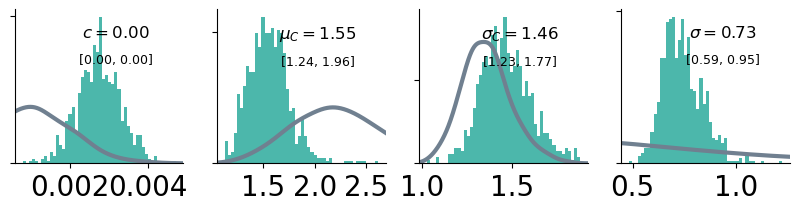

In [16]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(C_model, C_trace, 'c', dist_math='c', ax=axs[0])
cov19.plot.distribution(C_model, C_trace, 'mu_C', dist_math='\mu_C', ax=axs[1])
cov19.plot.distribution(C_model, C_trace, 'sigma_C', dist_math='\sigma_C', ax=axs[2])
cov19.plot.distribution(C_model, C_trace, 'sigma', dist_math='\sigma', ax=axs[3])

fig.savefig(f"figures/{tag}_distributions.png", dpi=300, bbox_inches="tight")

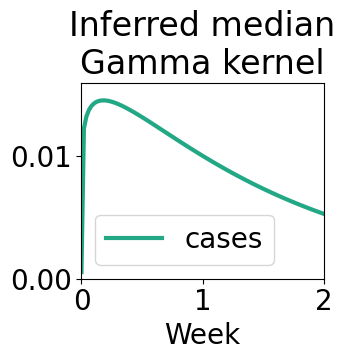

In [31]:
plot_gamma_kernel(C_trace, tag, {"mu": "mu_C", "sigma": "sigma_C", "label": "cases", "color": color_C})

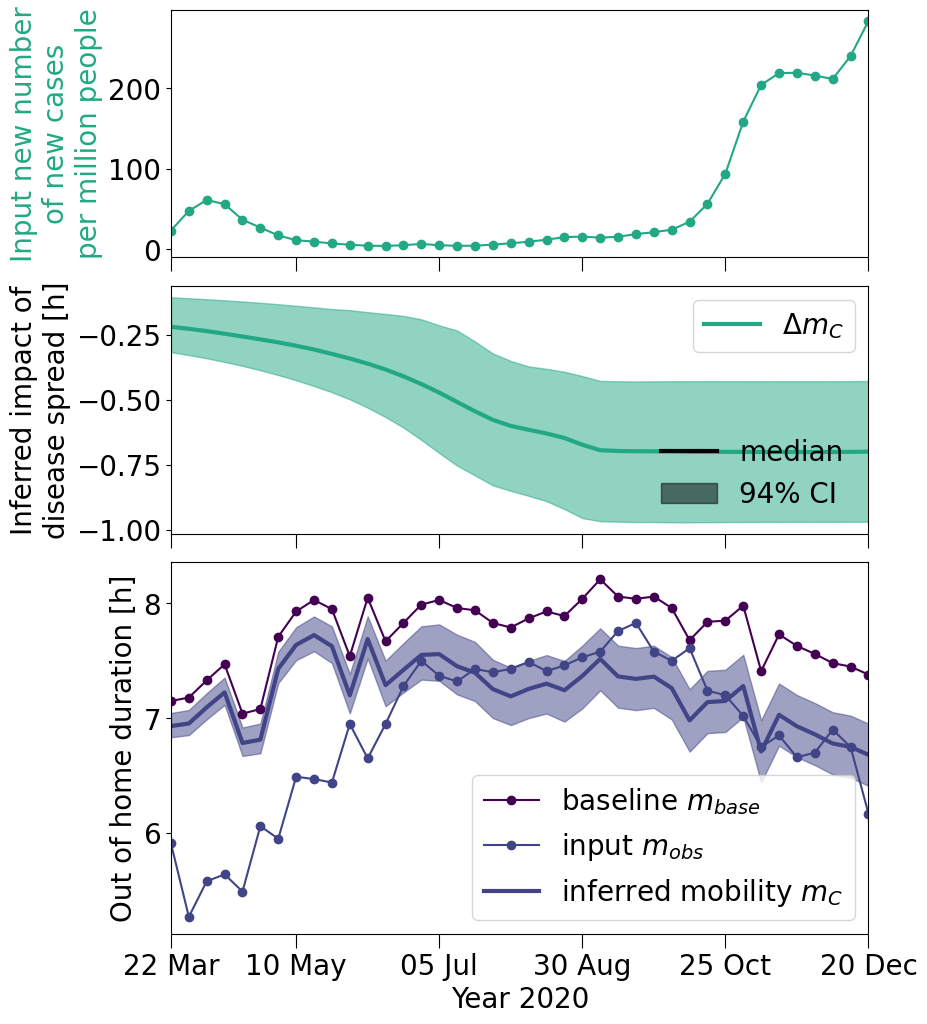

In [78]:
plot_inference_timeseries(
                          dates,
                          C_trace,
                          tag,
                          {
                            "constant": "cases",
                            "color": color_C,
                            "data_label": f"Input new number\nof new cases\nper million people",
                            "del": "del_m_C",
                            "del_label": "$\Delta m_C$",
                            "color_del": color_del_m_C,
                            "m": "m_C",
                            "m_label": "inferred mobility $m_{C}$",
                          },
                          )

## R

In [6]:
# load trace from file
tag = "R_model_test"
R_trace = load_trace(tag)

In [47]:
az.summary(R_trace, var_names=["a", "mu_R", "sigma_R", "sigma"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.90,0.06,0.80,1.01,0.00,0.00,836.93,597.70,1.00
mu_R,1.59,0.31,1.13,2.15,0.02,0.02,338.15,156.37,1.02
sigma_R,1.44,0.13,1.20,1.69,0.00,0.00,829.28,641.65,1.00
sigma,0.47,0.05,0.38,0.58,0.00,0.00,574.84,621.83,1.01


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


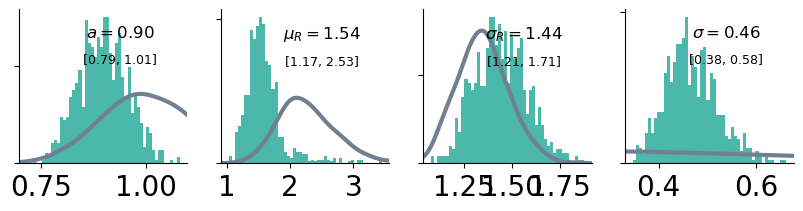

In [48]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(R_model, R_trace, 'a', dist_math='a', ax=axs[0])
cov19.plot.distribution(R_model, R_trace, 'mu_R', dist_math='\mu_R', ax=axs[1])
cov19.plot.distribution(R_model, R_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[2])
cov19.plot.distribution(R_model, R_trace, 'sigma', dist_math='\sigma', ax=axs[3])

fig.savefig(f"figures/{tag}_distributions.png", dpi=300, bbox_inches="tight")

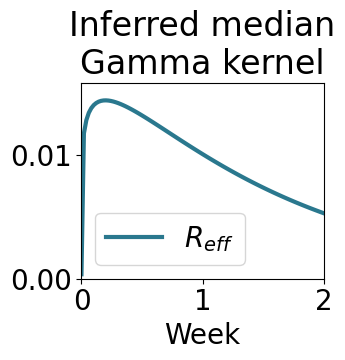

In [38]:
plot_gamma_kernel(R_trace, tag, {"mu": "mu_R", "sigma": "sigma_R", "label": "$R_{eff}$", "color": color_R})

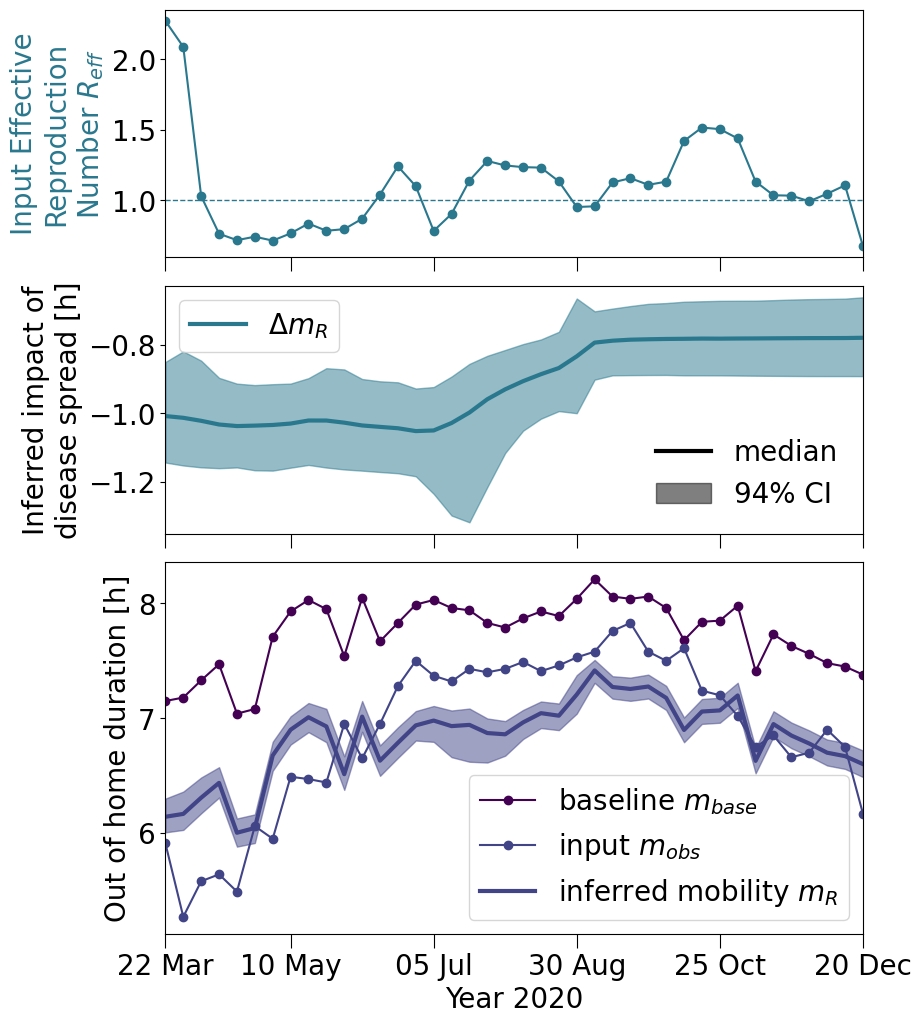

In [74]:
plot_inference_timeseries(
                          dates,
                          R_trace,
                          tag,
                          {
                            "constant": "R_eff", 
                            "color": color_R,
                            "data_label": f"Input Effective\nReproduction\nNumber $R_{{eff}}$",
                            "del": "del_m_R",
                            "del_label": "$\Delta m_R$",
                            "color_del": color_del_m_R,
                            "m": "m_R",
                            "m_label": "inferred mobility $m_{R}$",
                          },
                          )

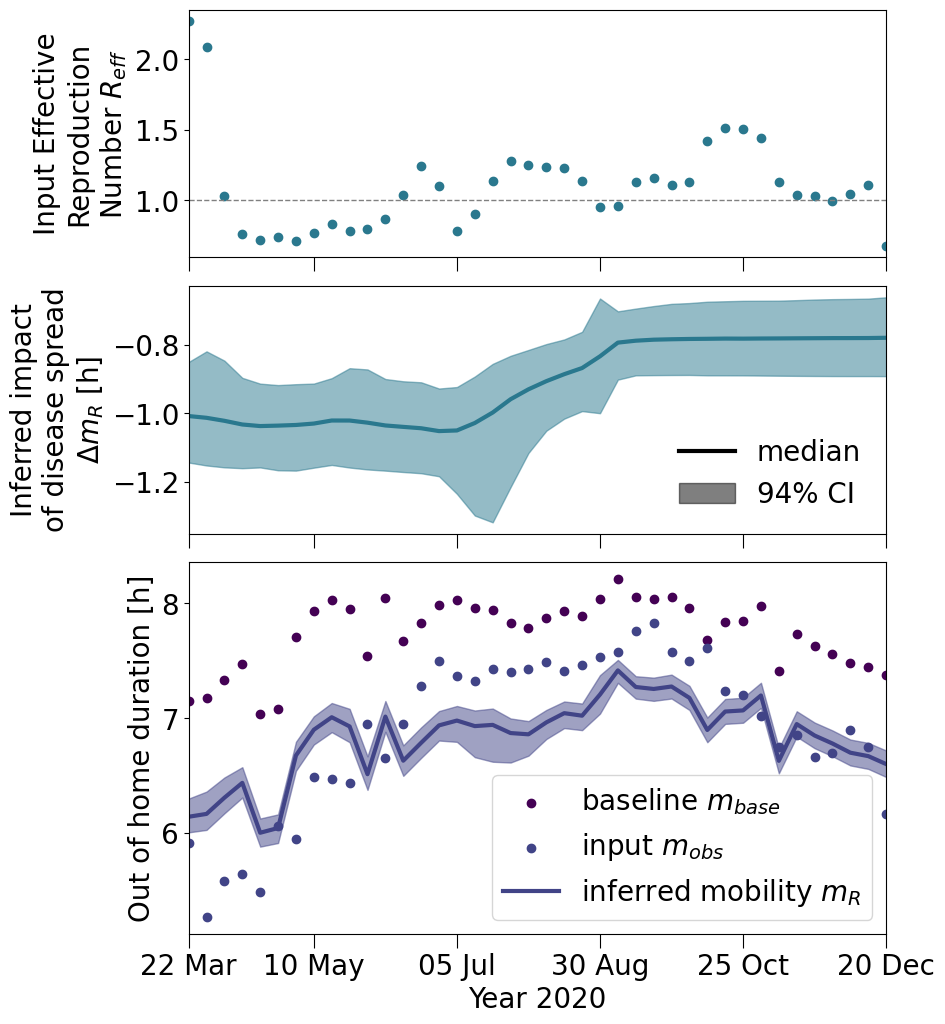

In [50]:
fig, axs = plt.subplots(3, 1, figsize=(9, 12), height_ratios=[2, 2, 3], sharex=True)

# upper plot
ax = axs[0]
ax.scatter(dates, R_trace.constant_data["R_eff"], color=color_R)
ax.hlines(1, dates[0], dates[-1], linestyle="--", color="grey", linewidth=1)
ax.set_ylabel(f"Input Effective\nReproduction\nNumber $R_{{eff}}$")
format_x_axis(ax, dates)

# middle plot
ax = axs[1]
plot_timeseries(ax, dates, R_trace.posterior['del_m_R'], "inferred impact of disease spread $\Delta m_R$", color_del_m_R)
format_x_axis(ax, dates)
# set y label
ax.set_ylabel("Inferred impact\nof disease spread\n$\Delta m_R$ [h]")
# create custom legend
## for median line and 94% CI
median_line = lines.Line2D([], [], color='black', linewidth=3, label="median")
ci_94 = patches.Patch(color='black', alpha=0.5, label="94% CI")
## create legend
legend = ax.legend(handles=[median_line, ci_94], loc="lower right", frameon=False)

# lower plot
ax = axs[2]
ax.scatter(dates, R_trace.constant_data["m_base"], label="baseline $m_{base}$", color=color_m_base)
ax.scatter(dates, R_trace.observed_data["likelihood"], label="input $m_{obs}$", color=color_m_obs)
plot_timeseries(ax, dates, R_trace.posterior['m_R'], "inferred mobility $m_R$", color_m_obs)
ax.legend()
format_x_axis(ax, dates, last=True)
# set y label
ax.set_ylabel("Out of home duration [h]")

plt.subplots_adjust(hspace=0.1)

# save figure
plt.savefig(f"figures/overview_{tag}.png", bbox_inches="tight")

## ICU

In [7]:
# load trace from file
tag = "ICU_model_test"
ICU_trace = load_trace(tag)

In [13]:
az.summary(ICU_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,0.018,0.003,0.012,0.023,0.000,0.000,699.0,280.0,1.02
mu_ICU,1.430,0.368,0.727,2.064,0.017,0.012,498.0,425.0,1.01
sigma_ICU,1.721,0.171,1.405,2.040,0.008,0.006,421.0,464.0,1.01
sigma,0.723,0.099,0.558,0.914,0.005,0.004,423.0,370.0,1.01
del_m_ICU[0],-0.289,0.047,-0.381,-0.204,0.002,0.001,691.0,338.0,1.01
...,...,...,...,...,...,...,...,...,...
m_ICU[35],6.739,0.142,6.475,7.007,0.005,0.004,710.0,293.0,1.02
m_ICU[36],6.669,0.142,6.401,6.934,0.005,0.004,709.0,293.0,1.02
m_ICU[37],6.590,0.142,6.321,6.854,0.005,0.004,708.0,293.0,1.02
m_ICU[38],6.560,0.142,6.291,6.825,0.005,0.004,707.0,293.0,1.02


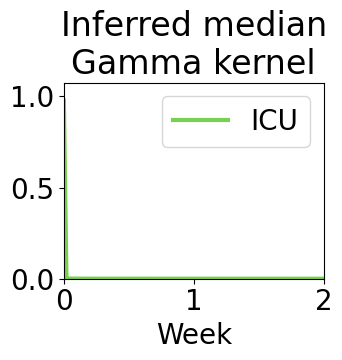

In [21]:
plot_gamma_kernel(ICU_trace, tag, {"mu": "mu_ICU", "sigma": "sigma_ICU", "label": "ICU", "color": color_ICU})

Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

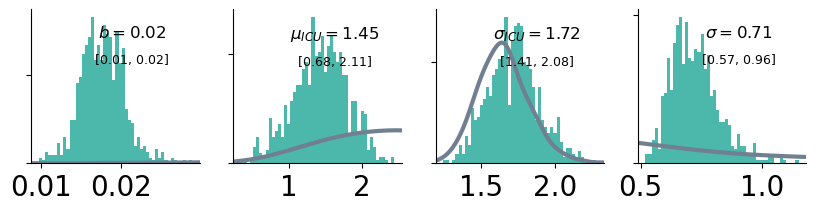

In [35]:
fig, axs = plt.subplots(1, 4, figsize=(10, 2))

cov19.plot.distribution(ICU_model, ICU_trace, 'b', dist_math='b', ax=axs[0])
cov19.plot.distribution(ICU_model, ICU_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1])
cov19.plot.distribution(ICU_model, ICU_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[2])
cov19.plot.distribution(ICU_model, ICU_trace, 'sigma', dist_math='\sigma', ax=axs[3])

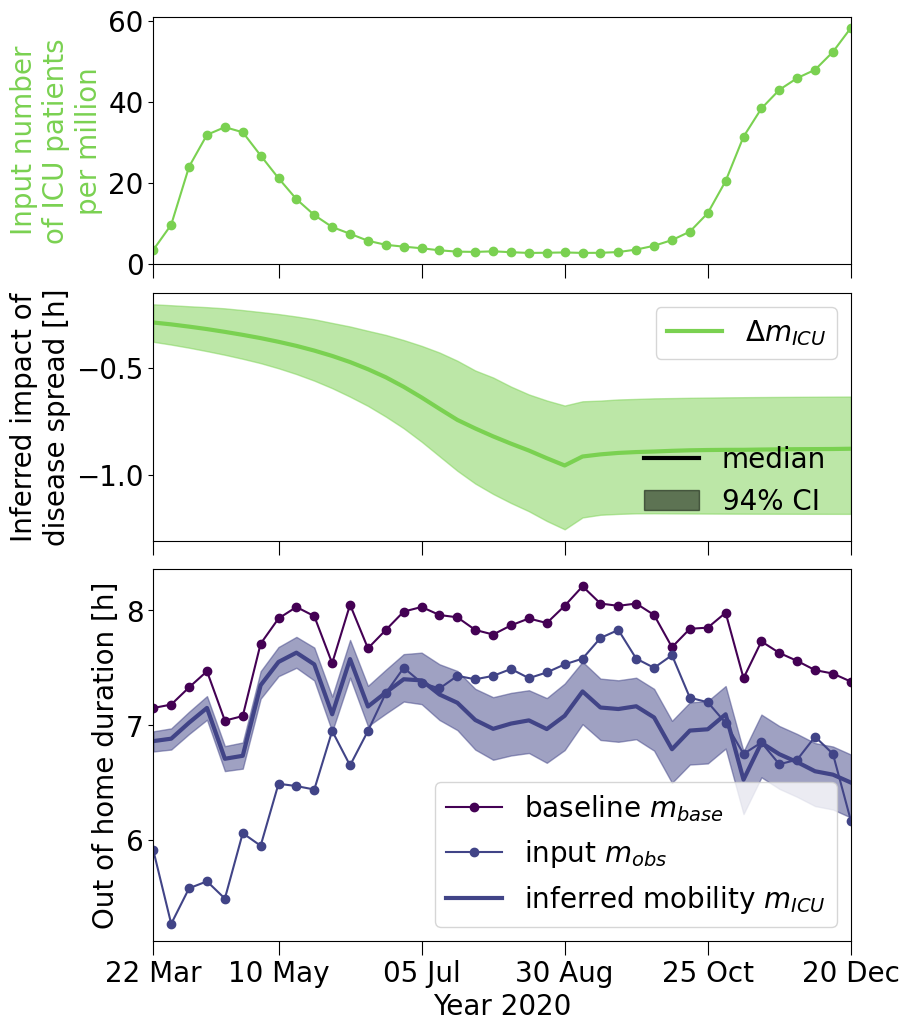

In [71]:
plot_inference_timeseries(
                          dates,
                          ICU_trace,
                          tag,
                          {
                            "constant": "ICU",
                            "color": color_ICU,
                            "data_label": f"Input number\nof ICU patients\nper million",
                            "del": "del_m_ICU",
                            "del_label": "$\Delta m_{ICU}$",
                            "color_del": color_del_m_ICU,
                            "m": "m_ICU",
                            "m_label": "inferred mobility $m_{ICU}$",
                          },
                          )

## R + cases model

In [8]:
tag = "R+cases_model_test"
RC_trace = load_trace(tag)

In [82]:
az.summary(RC_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.892,0.075,0.760,1.034,0.003,0.002,549.0,539.0,1.0
c,-0.001,0.000,-0.001,0.000,0.000,0.000,507.0,525.0,1.0
mu_R,1.569,0.242,1.135,1.990,0.012,0.009,534.0,326.0,1.0
sigma_R,1.475,0.135,1.217,1.717,0.005,0.004,721.0,641.0,1.0
mu_ICU,2.269,0.430,1.420,3.017,0.015,0.011,786.0,553.0,1.0
...,...,...,...,...,...,...,...,...,...
m[35],7.016,0.101,6.845,7.215,0.003,0.002,840.0,559.0,1.0
m[36],6.946,0.101,6.775,7.146,0.003,0.002,841.0,580.0,1.0
m[37],6.866,0.100,6.695,7.067,0.003,0.002,841.0,628.0,1.0
m[38],6.834,0.100,6.661,7.035,0.003,0.002,828.0,628.0,1.0


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [c]
INFO     [pymc] Sampling: [c]
Sampling: [mu_C]
INFO     [pymc] Sampling: [mu_C]
Sampling: [sigma_C]
INFO     [pymc] Sampling: [sigma_C]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

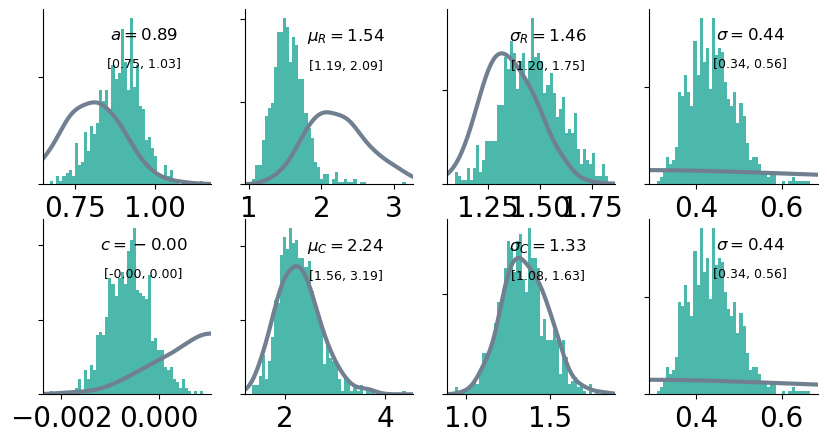

In [86]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(RC_model, RC_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(RC_model, RC_trace, 'c', dist_math='c', ax=axs[1,0])
cov19.plot.distribution(RC_model, RC_trace, 'mu_C', dist_math='\mu_{C}', ax=axs[1,1])
cov19.plot.distribution(RC_model, RC_trace, 'sigma_C', dist_math='\sigma_{C}', ax=axs[1,2])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(RC_model, RC_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

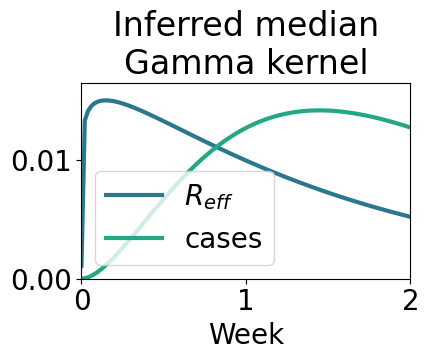

In [47]:
plot_gamma_kernel(RC_trace, 
                  tag, 
                  {"mu": "mu_R", "sigma": "sigma_R", "label": "$R_{eff}$", "color": color_R},
                  {"mu": "mu_C", "sigma": "sigma_C", "label": "cases", "color": color_C},
                  )

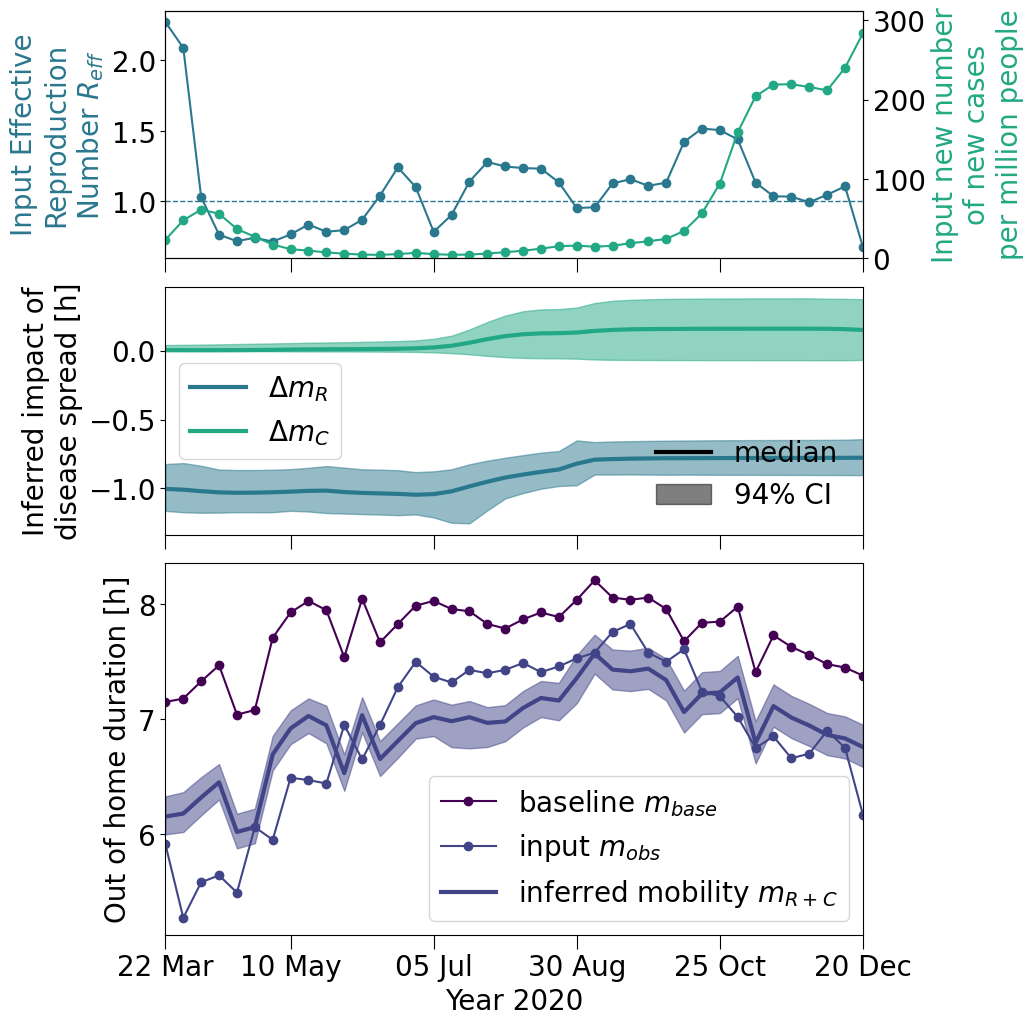

In [66]:
plot_inference_timeseries(
                          dates,
                          RC_trace,
                          tag,
                          {
                            "constant": "R_eff", 
                            "color": color_R,
                            "data_label": f"Input Effective\nReproduction\nNumber $R_{{eff}}$",
                            "del": "del_m_R",
                            "del_label": "$\Delta m_R$",
                            "color_del": color_del_m_R,
                            "m": "m",
                            "m_label": "inferred mobility $m_{R+C}$",
                          },
                          {
                            "constant": "cases",
                            "color": color_C,
                            "data_label": f"Input new number\nof new cases\nper million people",
                            "del": "del_m_C",
                            "del_label": "$\Delta m_C$",
                            "color_del": color_del_m_C,
                          },
                          )

## R + ICU model

In [9]:
tag = "joint_model_test"
joint_trace = load_trace(tag)

In [54]:
az.summary(joint_trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.850,0.084,0.693,1.006,0.004,0.003,499.0,409.0,1.00
b,-0.001,0.003,-0.006,0.004,0.000,0.000,549.0,447.0,1.00
mu_R,1.637,0.336,1.099,2.299,0.021,0.015,371.0,285.0,1.00
sigma_R,1.442,0.141,1.180,1.693,0.006,0.004,645.0,536.0,1.01
mu_ICU,2.251,0.458,1.493,3.217,0.015,0.011,876.0,736.0,1.00
...,...,...,...,...,...,...,...,...,...
m[35],6.945,0.111,6.741,7.172,0.003,0.002,1027.0,623.0,1.01
m[36],6.875,0.111,6.671,7.102,0.003,0.002,1027.0,623.0,1.01
m[37],6.795,0.111,6.592,7.021,0.003,0.002,1032.0,622.0,1.01
m[38],6.766,0.110,6.563,6.991,0.003,0.002,1040.0,648.0,1.01


Sampling: [a]
INFO     [pymc] Sampling: [a]
Sampling: [mu_R]
INFO     [pymc] Sampling: [mu_R]
Sampling: [sigma_R]
INFO     [pymc] Sampling: [sigma_R]
Sampling: [b]
INFO     [pymc] Sampling: [b]
Sampling: [mu_ICU]
INFO     [pymc] Sampling: [mu_ICU]
Sampling: [sigma_ICU]
INFO     [pymc] Sampling: [sigma_ICU]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]
Sampling: [sigma]
INFO     [pymc] Sampling: [sigma]


[<Axes: >]

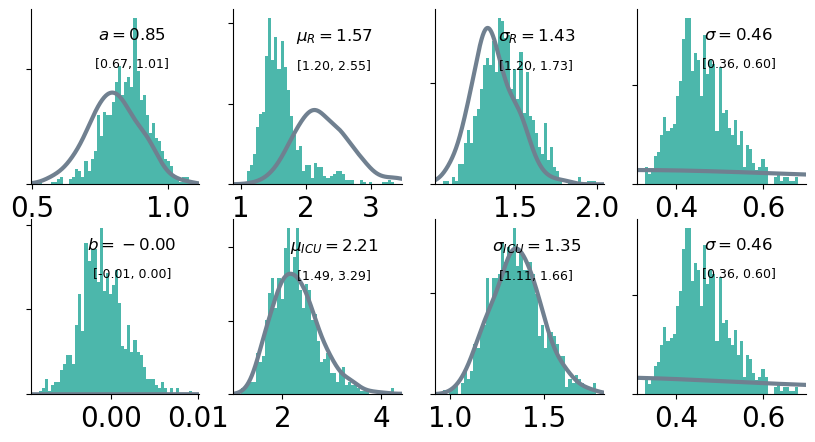

In [55]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5))

cov19.plot.distribution(joint_model, joint_trace, 'a', dist_math='a', ax=axs[0,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_R', dist_math='\mu_R', ax=axs[0,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_R', dist_math='\sigma_R', ax=axs[0,2])
cov19.plot.distribution(joint_model, joint_trace, 'b', dist_math='b', ax=axs[1,0])
cov19.plot.distribution(joint_model, joint_trace, 'mu_ICU', dist_math='\mu_{ICU}', ax=axs[1,1])
cov19.plot.distribution(joint_model, joint_trace, 'sigma_ICU', dist_math='\sigma_{ICU}', ax=axs[1,2])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[0,3])
cov19.plot.distribution(joint_model, joint_trace, 'sigma', dist_math='\sigma', ax=axs[1,3])

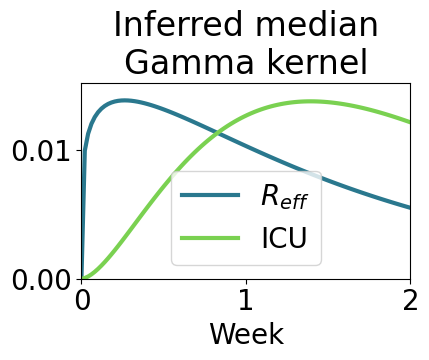

In [49]:
plot_gamma_kernel(joint_trace,
                  tag,
                  {"mu": "mu_R", "sigma": "sigma_R", "label": "$R_{eff}$", "color": color_R},
                  {"mu": "mu_ICU", "sigma": "sigma_ICU", "label": "ICU", "color": color_ICU}
                  )

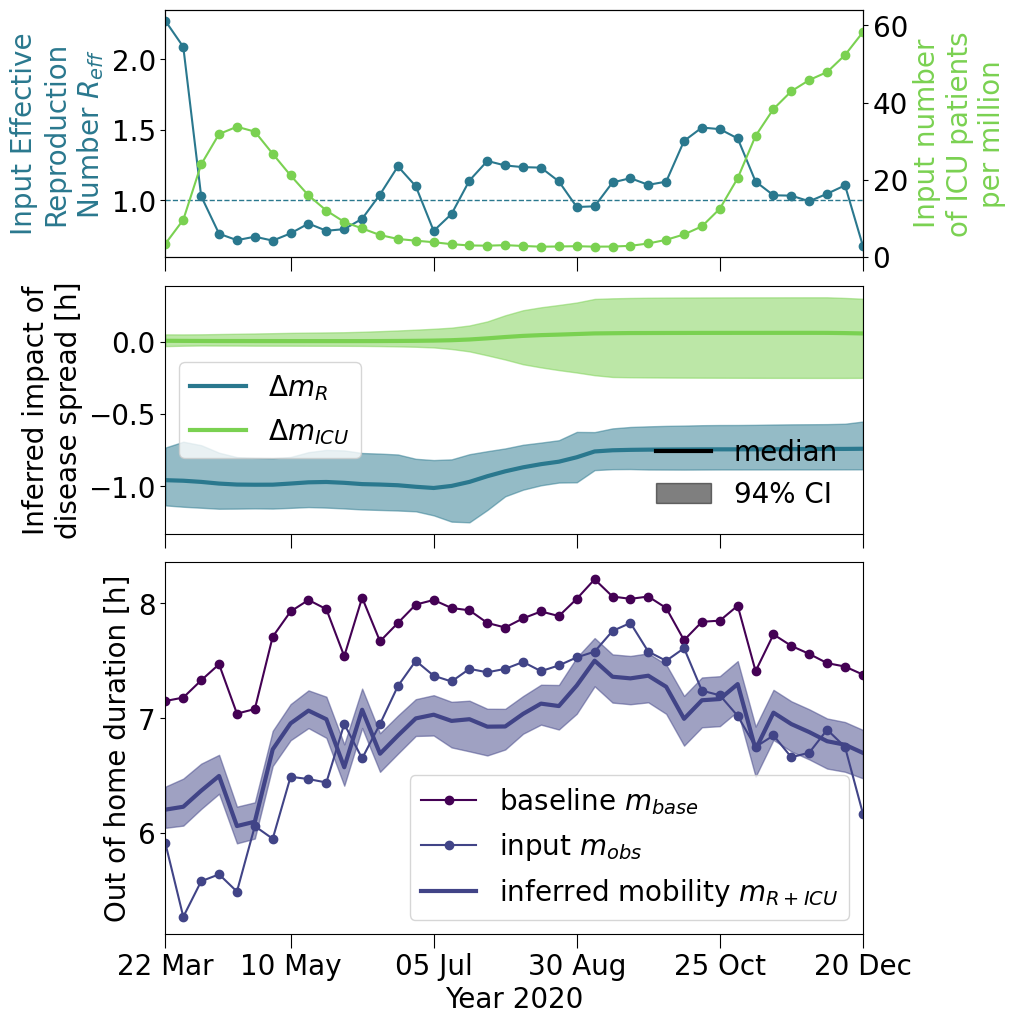

In [68]:
plot_inference_timeseries(
                          dates,
                          joint_trace,
                          tag,
                          {
                            "constant": "R_eff", 
                            "color": color_R,
                            "data_label": f"Input Effective\nReproduction\nNumber $R_{{eff}}$",
                            "del": "del_m_R",
                            "del_label": "$\Delta m_R$",
                            "color_del": color_del_m_R,
                            "m": "m",
                            "m_label": "inferred mobility $m_{R+ICU}$",
                          },
                          {
                            "constant": "ICU",
                            "color": color_ICU,
                            "data_label": f"Input number\nof ICU patients\nper million",
                            "del": "del_m_ICU",
                            "del_label": "$\Delta m_{ICU}$",
                            "color_del": color_del_m_ICU,
                          }
                          )

# Comparison

In [29]:
with ICU_model:
    pm.compute_log_likelihood(ICU_trace)

In [30]:
with joint_model:
    pm.compute_log_likelihood(joint_trace)

In [32]:
with RC_model:
    pm.compute_log_likelihood(RC_trace)

In [39]:
RC_trace

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
	> constant_data

In [46]:
loo = az.compare({
    "R + ICU": joint_trace, 
    "R": R_trace, 
    "ICU": ICU_trace,
    "C": C_trace,
    "R + C": RC_trace,
    }, ic="loo")
az.plot_compare(loo)

ValueError: The number of observations should be the same across all models

In [34]:
waic = az.compare({
    "R + ICU": joint_trace, 
    "R": R_trace, 
    "ICU": ICU_trace,
    "C": C_trace,
    "R + C": RC_trace,
    }, ic="waic")
az.plot_compare(waic)

c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\arviz\stats\stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\arviz\stats\stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
c:\Users\iftek\mambaforge\envs\feedback_inference\lib\site-packages\arviz\stats\stats.py:1645: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


ValueError: The number of observations should be the same across all models